# 4.2 SGD

## (a)


As we will see, one of the hyperparameters that affects training the most is the learning rate. Let's
see that in practice in our toy example. Run the SGD example above with three other values for the
learning rate: 1e1, 1e2, and 1e3, for just 10 training iterations. What happens with the loss for each
of these learning rates? Does it decay faster, slower, or does it diverge (i.e., increase over the course of
training)?
Deliverable: A one-two sentence response with the behaviors you observed.


In [ ]:
from collections.abc import Callable, Iterable
from typing import Optional
import torch
import math
class SGD(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3):
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")
        defaults = {"lr": lr}
        super().__init__(params, defaults)

    def step(self, closure: Optional[Callable] = None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            lr = group["lr"] # Get the learning rate.
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p] # Get state associated with p.
                t = state.get("t", 0) # Get iteration number from the state, or initial value.
                grad = p.grad.data # Get the gradient of loss with respect to p.
                p.data -= lr / math.sqrt(t + 1) * grad # Update weight tensor in-place.
                state["t"] = t + 1 # Increment iteration number.
        return loss

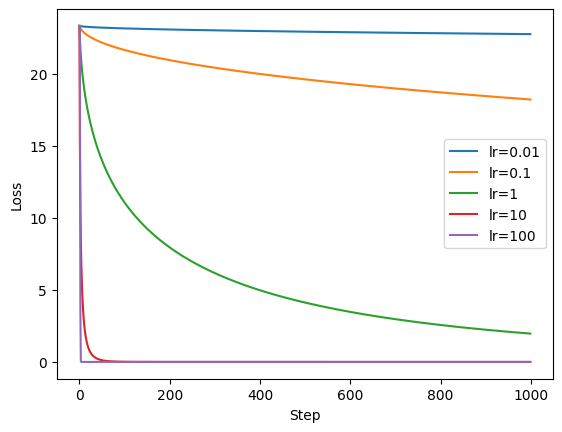

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(28)  # for reproducibility

records = {}

# create one base initialization
base_weights = 5 * torch.randn((10, 10))

for pw in range(-2, 3):
    lr = 10**pw

    # start each run from the same initialization
    weights = torch.nn.Parameter(base_weights.clone())
    opt = SGD([weights], lr=lr)

    current_record = []
    for t in range(1000):
        opt.zero_grad()
        loss = (weights**2).mean()
        current_record.append(loss.item())
        loss.backward()
        opt.step()

    records[lr] = current_record

# plot
for lr, rec in records.items():
    plt.plot(rec, label=f"lr={lr}")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()


# Answer: lr = 100 seems to be the best choice of LR among the 5 candidates;
# when lr is too small, progress is slow (but viable), when lr is too large, it is unstable and no progress. (lr = 1000, loss increases exponentially)

# 4.3 AdamW

## Let us compute how much memory and compute running AdamW requires. Assume we are using float32 for every tensor.
(a) How much peak memory does running AdamW require? Decompose your answer based on the memory usage of the parameters, activations, gradients, and optimizer state. Express your answer in terms of the **batch_size** and the model hyperparameters (**vocab_size, context_length,num_layers, d_model, num_heads**). Assume $d_{ff} = 4d_{model}$.

For simplicity, when calculating memory usage of activations, consider only the following components:

• Transformer block
- RMSNorm(s)
- Multi-head self-attention sublayer: $QKV$ projections, $Q^T K$ matrix multiply, softmax, weighted sum of values, output projection.
- Position-wise feed-forward: W1 matrix multiply, SiLU, W2 matrix multiply

• final RMSNorm

• output embedding

• cross-entropy on logits

Deliverable: An algebraic expression for each of parameters, activations, gradients, and optimizer state, as well as the total.

### Answer:

Denote total number of parameters $P$, total number of activations $A$, then we have (assuming all are float32):

$$
\begin{aligned}
M_{param} &= 32P\\
M_{gradient}&= 32P\\
M_{optimizer}&= 32 * (2P)\\
M_{activations}&= 32A\\
\end{aligned}
$$

Thus in total, we have:

$$
M_{forward} = M_{param} + M_{optimizer} + M_{activations} = 96P + 32A\\
M_{backward} = M_{param} + M_{gradient} + M_{optimizer} + M_{activations} = 128P + 32A\\
$$

The peak memory is $128P + 32A$. From assignment 1.3.6(b), we previously found that:

token embedding: (vocab_size, d_model)

transformer block * num_layers:

- RMS norm: (d_model, )
- Multi-Head self-attention (across all heads):
  - Wq: (num_heads * (d_model / num_heads), d_model)
  - Wk: (num_heads * (d_model / num_heads), d_model)
  - Wv: (num_heads * (d_model / num_heads), d_model)
  - Wo: (d_model, d_model)

**note** : Multi-head self-attention sublayer: $Q K V$ projections, $Q^{\top} K$ matrix multiply, softmax, weighted sum of values, output projection.

Activations: $(3 * \text{batch} * \text{context} * \text{d_model}) + (\text{batch} * \text{context}^2 * \text{heads}) + (\text{batch} * \text{context} * \text{d_model}) + (\text{batch} * \text{context} * \text{d_model})$


- RMS norm: (d_model, )
- FFN (SwiGLU):
  - W1: (d_model, d_ff)
  - W2: (d_ff, d_model)
  - W3: (d_model, d_ff)

final RMS norm (gain vector): (d_model, )

final linear activation: (vocab_size, d_model)



```
trainable_params =
            vocab_size * d_model +
            num_layers * (d_model*2 + d_model*d_model*4 + d_model*d_ff*3) +
            d_model + vocab_size * d_model

activations = batch_size * context_length * (
            d_model +
            num_layers * (
                          2 * d_model +
                          (3 * d_model +
                            context_length * num_heads +
                            2 * d_model
                          ) +
                          (d_ff + d_model + d_ff)
                          ) +
            d_model + vocab_size)
```



In [12]:
vocab_size = 50257
context_length = 1024
num_layers = 48
d_model = 1600
num_heads = 25
d_ff = 6400
data_size = 32
batch_size = 1

trainable_params = vocab_size * d_model + num_layers * (d_model*2 + d_model*d_model*4 + d_model*d_ff*3) + d_model + vocab_size * d_model
activations = batch_size * context_length * (d_model + num_layers * (2 * d_model +(3 * d_model + context_length * num_heads +2 * d_model) + (d_ff + d_model + d_ff)) + d_model + vocab_size)
print(trainable_params)
param_memory = 4 * trainable_params * data_size
activations_memory = activations * data_size
peak_memory = param_memory + activations_memory
print(f'total param memory: {param_memory} bits, or {param_memory/8/1024/1024/1024} GB')
print(f'total activations memory (per batch): {activations_memory} bits, or {activations_memory/8/1024/1024/1024} GB')
print(f'peak memory: {peak_memory} bits, or {peak_memory/8/1024/1024/1024} GB')

2127057600
total param memory: 272263372800 bits, or 31.69562816619873 GB
total activations memory (per batch): 82282315776 bits, or 9.578922271728516 GB
peak memory: 354545688576 bits, or 41.274550437927246 GB


(b) Instantiate your answer for a GPT-2 XL-shaped model to get an expression that only depends on the batch_size. What is the maximum batch size you can use and still fit within 80GB memory?

Deliverable: An expression that looks like a ·batch_size + b for numerical values a, b, and a number representing the maximum batch size.

In [ ]:
# Answer:
## You can only run 5 batches (i.e. 31.69 + 5 * 9.58 < 80)

(c) How many FLOPs does running one step of AdamW take?

Deliverable: An algebraic expression, with a brief justification

### Answer:

Code for AdamW as follows:

```python
m = beta1 * m + (1-beta1) * grad                  #3
v = beta2 * v + (1-beta2) * (grad **2)            #4
lr_t = lr * math.sqrt(1-beta2**t)/(1-beta1**t)
p.data -= lr_t * (m/v**0.5 + epsilon)             #5
p.data -= weight_decay * lr * p.data              #3
```

Which has 15 FLOPS per param. Thus the total FLOPS are $15P = 31.5 billion$

(d) Model FLOPs utilization (MFU) is defined as the ratio of observed throughput (tokens per second) relative to the hardware's theoretical peak FLOP throughput [Chowdhery et al., 2022]. An NVIDIA A100 GPU has a theoretical peak of 19.5 teraFLOP/s for float32 operations.

Assuming you are able to get 50% MFU, how long would it take to train a GPT-2 XL for 400K steps and a batch size of 1024 on a single A100?

Following Kaplan et al. [2020] and Hoffmann et al. [2022], assume that the backward pass has twice the FLOPs of the forward pass.

Deliverable: The number of days training would take, with a brief justification

### Answer:

With the simplifying assumption that the backward pass has twice the FLOPs of forward pass, and we previously (in assignment 1.3.6(b)) computed that one forward pass for 1024 tokens (one batch) takes 4.52e12 FLOPs, or 4.52 tFLOPS.



In [17]:
total_flops = 400  * 1000 * (4.52 + 2 * 4.52 + 31.5 * 0.001)
print(f'We have total FLOPs = 400K * 1024 * (4.52 + 2 * 4.52 + 31.5e-3) = {total_flops:.2f} tFLOPs')

total_seconds = total_flops / (0.5 * 19.5)
print(f'Total seconds needed = {total_seconds:.2f}, or {total_seconds/3600/24} days')

We have total FLOPs = 400K * 1024 * (4.52 + 2 * 4.52 + 31.5e-3) = 5436600.00 tFLOPs
Total seconds needed = 557600.00, or 6.453703703703702 days
